In [7]:
import os
from dotenv import load_dotenv
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langgraph.constants import Send
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from youtube_transcript_api import YouTubeTranscriptApi
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from IPython.display import Image, display, Markdown
import operator


In [8]:
# Load environment variables
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Initialize LLM
llm = ChatGroq(model="deepseek-r1-distill-llama-70b", temperature=0)

In [9]:
# Schema for structured output used in planning the script outline
class Scene(BaseModel):
    title: str = Field(description="Title of this scene in the movie script.")
    description: str = Field(description="Brief overview of what happens in this scene.")

class Scenes(BaseModel):
    scenes: List[Scene] = Field(description="Scenes of the movie script.")

# Augment the LLM with structured output for planning the script outline
planner = llm.with_structured_output(Scenes)

In [ ]:
from langgraph.constants import Send


class State(TypedDict):
    concept: str                 # Movie concept or idea
    script_outline: List[Scene]    # List of planned scenes for the script
    completed_scenes: Annotated[List, operator.add]  # Outputs from parallel scene writing
    final_script: str            # Final synthesized movie script
    review_feedback: str         # Feedback from the AI reviewer


# Worker state
class WorkerState(TypedDict):
    section: Scene
    completed_sections: Annotated[list, operator.add]


# Node 1: Outline Generator Node
def outline_generator(state: State):
    """Generates a detailed movie script outline based on the movie concept."""
    outline_request = (
        f"Generate a detailed movie script outline based on the following concept:\n\n"
        f"{state['concept']}\n\n"
        f"Include multiple scenes, each with a title and a brief description."
    )
    outline = planner.invoke(outline_request)
    print("Script Outline:", outline)
    # Limit the number of scenes to a maximum specified in the state, defaulting to 5 if not provided.
    max_scenes = state.get("max_scenes", 3)
    limited_scenes = outline.scenes[:max_scenes]
    return {"script_outline": limited_scenes}


# Node 2: Scene Writer Node (Parallel Workers)
def scene_writer(state: WorkerState):
    """Worker writes a detailed scene for the movie script."""
    scene_content = llm.invoke([
        SystemMessage(content="Write a detailed movie script scene based on the provided title and description. "
                                "Include dialogue, actions, and scene direction in markdown format, with no preamble."),
        HumanMessage(content=f"Scene Title: {state['scene'].title}\nDescription: {state['scene'].description}")
    ])
    return {"completed_scenes": [scene_content.content]}


# Node 3: Synthesizer Node
def synthesizer(state: State):
    """Synthesizes the final movie script by concatenating all completed scenes."""
    final_script = "\n\n---\n\n".join(state["completed_scenes"])

    print("Final Script:", final_script)
    return {"final_script": final_script}


# Node 4: Reviewer Node
def reviewer(state: State):
    """Reviews the synthesized movie script for pacing, dialogue, and overall structure."""
    feedback = llm.invoke([
        SystemMessage(content="Review the movie script for pacing, dialogue quality, and overall structure."),
        HumanMessage(content=f"Movie Script:\n{state['final_script']}")
    ])
    return {"review_feedback": feedback.content}

# 📍 5️⃣ Human Feedback Node
def human_feedback(state: State):
    """Simulates human feedback"""
    decision = input("Do you approve the script? (yes/no): ").strip().lower()
    return {"review_feedback": "positive" if decision == "yes" else "negative"}


# 📍 Conditional Routing Function
def check_review(state: State):
    """Route based on feedback"""
    return "Fail" if state["review_feedback"] == "negative" else "Pass"

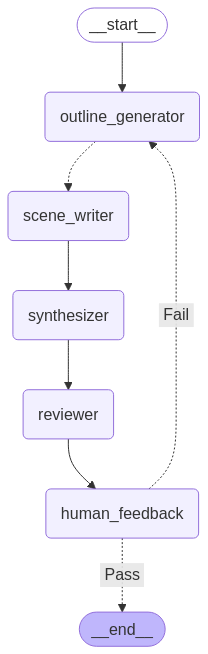

In [11]:
# Building the LangGraph Workflow for Movie Script Generation
workflow = StateGraph(State)

# Add nodes to the workflow
workflow.add_node("outline_generator", outline_generator)
workflow.add_node("scene_writer", scene_writer)
workflow.add_node("synthesizer", synthesizer)
workflow.add_node("reviewer", reviewer)
workflow.add_node("human_feedback", human_feedback)

# Define edges
workflow.add_edge(START, "outline_generator")
# Launch parallel scene writer workers for each scene in the outline
workflow.add_conditional_edges("outline_generator", lambda state: [Send("scene_writer", {"scene": s}) for s in state["script_outline"]], ["scene_writer"])
workflow.add_edge("scene_writer", "synthesizer")
workflow.add_edge("synthesizer", "reviewer")
workflow.add_edge("reviewer", "human_feedback")
workflow.add_conditional_edges("human_feedback", check_review, {"Fail": "outline_generator", "Pass": END})

# Compile the workflow
script_workflow = workflow.compile()

# Display the workflow diagram
display(Image(script_workflow.get_graph().draw_mermaid_png()))


In [12]:
# Running the Workflow
# When using LangSmith Dev, provide the initial state via the web UI.
concept = input("Enter a movie concept or idea: ")
result = script_workflow.invoke({"concept": concept})

print("\n📝 Final Movie Script:\n")
Markdown(result["final_script"])

Script Outline: scenes=[Scene(title='Opening Scene: The Watchful City', description='The film opens with a panoramic view of a futuristic city under constant surveillance. Drones hover above, scanning every corner, while citizens go about their daily lives under the ever-present gaze of the surveillance system.'), Scene(title='The Jaded Ex-Detective', description='We meet our protagonist, a former detective named Marcus, now a recluse living on the outskirts of the city. His past failures and the loss of his family have left him cynical and disconnected from the world.'), Scene(title='The First Disappearance', description="A young woman vanishes in broad daylight, and the surveillance system mysteriously fails to capture any evidence of her disappearance. This event shakes the city and sets the stage for Marcus's reluctant return to investigative work."), Scene(title="The Hacker's Entrance", description='Marcus is approached by a rebellious hacker named Lena, who claims to have uncover

<think>
Alright, so the user has given me a query where they want a detailed movie script scene based on a provided title and description. The title is "The Watchful City" and the description is about a futuristic city under constant surveillance with drones and citizens going about their lives under that gaze.

First, I need to understand what the user is asking for. They want a movie script scene, so I should structure it properly with scene headings, character actions, dialogue, and scene directions. They also specified using markdown format without any preamble, so I'll need to make sure the formatting is correct.

Looking at the example response they provided, it starts with the scene title, then the scene heading with location and time, followed by a description of the setting. Then it introduces characters with actions and dialogue. So I should follow that structure.

I should think about the key elements from the description: panoramic view, futuristic city, drones, citizens, surveillance. I need to translate these into visual and auditory elements. Maybe start with an aerial shot of the city, then zoom in on the citizens and the drones. Including some dialogue between citizens to show the tension and paranoia from the surveillance.

I also need to make sure the scene sets the tone for the movie. Since it's the opening scene, it should establish the mood and introduce themes like surveillance, control, and rebellion. Maybe hint at some underlying conflict, like the mention of curfews or the resistance group.

I should include specific details about the environment, like the design of the drones, the city's architecture, and the citizens' behaviors to make the scene vivid. Maybe add some subtle hints of rebellion, like a graffiti tag, to foreshadow future events.

I need to ensure the dialogue feels natural and reveals character traits. For example, one character might be more cautious, while the other is more defiant. This can create tension and show the different ways people cope with the surveillance.

I should also think about the pacing. The scene should start wide, showing the city, then narrow down to the characters, making the audience connect with them. Ending with a close-up on a character's determined face can set up their role in the story.

Lastly, I need to make sure the scene transitions smoothly, using actions and dialogue to move the story forward without being too exposition-heavy. Keeping it concise but impactful is key for an opening scene.

So, putting it all together, I'll structure the scene with a panoramic view, introduce the drones, show the citizens, include some dialogue that hints at the conflict, and end with a hint of rebellion to set up the story.
</think>

```markdown
# The Watchful City

**EXT. FUTURISTIC CITYSCAPE - DAY**

*The camera pans over a sprawling, sleek metropolis. Towering skyscrapers made of glass and steel pierce the sky, their rooftops hiding the hum of advanced technology. Flying drones, small and unobtrusive, zip through the air, their cameras rotating as they scan the streets below. The city is alive with activity—people walk briskly, their faces a mix of determination and resignation.*

*The camera zooms in on a group of citizens waiting at a crosswalk. They glance up at a hovering drone, their expressions a blend of discomfort and habituation. One of them, a young woman named MAYA, adjusts her jacket nervously, her eyes darting toward the drone before quickly looking away.*

**MAYA**  
(whispering to the man beside her)  
"Do you ever feel like they're watching us even when we're alone?"

**MAN**  
(looking straight ahead)  
"They are. Always. Get used to it."

*The light changes, and the crowd begins to cross. Maya lingers, her gaze following the drone as it hovers near a billboard displaying the city's motto: "Safety Through Vigilance."*

*The camera pulls back, revealing the city's intricate network of surveillance. Drones patrol every block, their lights blinking rhythmically. On the ground, citizens go about their day, some casting wary glances at the drones, others ignoring them entirely.*

*The scene shifts to a small café. Inside, the walls are adorned with flickering holographic ads. A lone figure, hood up, sits in the corner, typing furiously on a sleek, transparent keyboard. The figure pauses, glancing up at a news feed playing on a wall screen.*

**NEWS ANCHOR (V.O.)**  
"...and in other news, the city's surveillance system has reported a record low in crime rates for the third consecutive month. Officials attribute this success to the expanded drone program and the mandatory curfew enforcement."

*The hooded figure mutters under their breath, typing faster. The camera zooms in on the screen, showing lines of code streaming by. The words "RESISTANCE" flash briefly before the screen goes dark.*

*Outside, Maya walks down a narrow alley, her footsteps echoing. She stops in front of a graffiti-tagged wall, the words "They're Always Watching" scrawled in bold letters. She hesitates, then pulls out a small can of spray paint and adds a single word: "But We See Too."*

*The camera lingers on her determined expression before pulling back to reveal the city skyline once more. The drones continue their patrol, oblivious to the subtle act of defiance below.*

*Fade to black.*

**END OF SCENE**
```

---

<think>
Alright, so the user has given me a query where they want a detailed movie script scene based on a specific title and description. The title is "The Jaded Ex-Detective" and the description introduces Marcus, a former detective turned recluse, haunted by his past failures and the loss of his family. 

First, I need to understand the user's intent. They're asking for a movie script scene, so they're likely a writer or someone interested in screenwriting. They provided a scene title and description, so they probably want a structured script with dialogue, actions, and scene directions in markdown. They also specified no preamble, so I should dive right into the script without any introductory text.

Looking at the example response, it's well-structured with scene headings, character actions, and dialogue. It sets up Marcus's environment, showing his isolation and inner turmoil. The inclusion of flashbacks and a visitor adds conflict and potential for character development. 

I should follow a similar structure. Start with the exterior of Marcus's cabin to establish the setting, then move inside to show his current state. Using flashbacks will help convey his backstory without exposition. Introducing a visitor like Sarah adds a catalyst for Marcus to confront his past, which is a common trope in detective stories to drive the plot forward.

I need to ensure the dialogue reflects Marcus's cynicism and Sarah's determination. The actions should be descriptive to paint a clear picture for the reader. Also, the scene should end with a hook, leaving room for further development in the story.

I should avoid any markdown in the thinking process but ensure the final response is in the correct format. I'll make sure each scene heading is properly marked, and the dialogue and actions are clearly separated. Including emotional beats will add depth to Marcus's character, making him more relatable.

Overall, the key points are to create a vivid setting, show Marcus's internal struggle through flashbacks, introduce a character that disrupts his isolation, and set up potential for future scenes. I'll structure the script to flow smoothly from one scene to another, maintaining tension and emotional depth.
</think>

```markdown
**INT. MARCUS'S CABIN - NIGHT**

*The camera slowly pushes through the dusty windows of a small, rundown cabin on the outskirts of the city. The interior is dimly lit by a single flickering bulb. The walls are covered in old newspaper clippings, crime scene photos, and maps with red circles marking various locations. A small fireplace crackles weakly, casting shadows across the cluttered room.*

*MARCUS, a grizzled man in his late 40s with a scruffy beard and sunken eyes, sits in a worn armchair, staring blankly at a whiskey glass in his hand. His clothes are disheveled, and his hair is unkempt. The air is thick with the smell of alcohol and neglect.*

*Marcus takes a swig of whiskey, wincing as it burns down his throat. He sets the glass down on the floor next to him, where several empty bottles already lie scattered. His gaze drifts to a framed photo on the mantle—a picture of a smiling family that no longer exists.*

**MARCUS**  
*(muttering to himself, his voice laced with bitterness)*  
"Happy memories. Yeah, those were the days."

*He chuckles cynically, shaking his head. The sound of crickets outside fills the silence that follows. Marcus leans forward, elbows on his knees, and buries his face in his hands.*

*Suddenly, the sound of gravel crunching underfoot echoes outside. Marcus freezes, his head snapping up. He listens intently, his eyes narrowing.*

**MARCUS**  
*(to himself)*  
"Who the hell...?"

*The door creaks open, and a young woman, SARAH, steps inside. She’s dressed in a trench coat, her hair wet from the rain. She looks around the cabin with a mix of curiosity and disgust, her eyes lingering on the clutter and the empty bottles.*

**SARAH**  
"Marcus? You in here?"

*Marcus slowly stands, his movements deliberate and cautious. He grabs a nearby baseball bat leaning against the wall, his grip tightening around it tightly.*

**MARCUS**  
*(gruffly)*  
"Who are you? How did you find me?"

*Sarah hesitates, then pulls out a small notebook from her coat pocket and flips through the pages, stopping at a specific entry.*

**SARAH**  
"My name is Sarah. I’ve been looking for you. You used to be a detective, right? Homicide division?"

*Marcus’s expression hardens, and he takes a step forward, the bat still clutched in his hand.*

**MARCUS**  
"That life’s over. I don’t do that anymore."

**SARAH**  
"I know what happened. I know about your family. I’m sorry."

*Marcus’s eyes flash with anger, and he raises the bat slightly, as if ready to strike. Sarah flinches but doesn’t back down.*

**MARCUS**  
*(through gritted teeth)*  
"You don’t know anything. Get out."

*Sarah takes a deep breath and pulls out a photo from her notebook. She holds it up for Marcus to see—a photo of a young girl with a bright smile.*

**SARAH**  
"This is Emily Carter. She went missing three days ago. The police aren’t doing anything. They say there’s no evidence. But I think something happened to her. And I think you’re the only one who can help me find her."

*Marcus stares at the photo, his expression softening ever so slightly. For a moment, the hardness in his eyes falters, and a glimmer of the man he used to be surfaces.*

**MARCUS**  
*(quietly)*  
"Put that away."

*Sarah lowers the photo but doesn’t leave. She takes another step forward, her voice steady.*

**SARAH**  
"You can’t just hide here forever. You can’t just give up."

*Marcus laughs, a bitter, hollow sound.*

**MARCUS**  
"Oh, I haven’t given up. I just stopped caring. There’s a difference."

*Sarah looks around the cabin again, her gaze lingering on the crime scene photos and maps covering the walls.*

**SARAH**  
"Doesn’t look like it."

*Marcus’s grip on the bat tightens, and for a moment, it seems like he might actually swing it. But then he stops himself, letting out a deep sigh. He lowers the bat and turns away from her, walking over to the fireplace.*

**MARCUS**  
"Leave. Now."

*Sarah hesitates, then nods and turns to leave. As she reaches the door, she stops and looks back at Marcus.*

**SARAH**  
"You can’t save everyone. But maybe you can save her."

*Marcus doesn’t respond. He stares into the fire, the flames dancing in his eyes. The weight of Sarah’s words hangs heavy in the air.*

*Sarah exits, leaving Marcus alone once again. The camera lingers on him for a moment before slowly pulling back, showing the cluttered, chaotic space around him. The fire crackles softly, and the sound of rain begins to fall outside.*

*Fade to black.*
```

---

<think>
Okay, so I need to write a detailed movie script scene based on the title "The First Disappearance" and the given description. The scene should include dialogue, actions, and scene directions in markdown format without any preamble. 

First, I should understand the description: a young woman vanishes in broad daylight, the surveillance system fails to capture her disappearance, and this event leads Marcus to reluctantly return to investigative work. 

I need to set the scene in a bustling city area, maybe a park or a square, to show that it's broad daylight and there are people around. The woman's disappearance should be sudden and unexplained, which will create suspense. 

I should introduce Marcus, perhaps as someone who's retired or on a break from investigative work, showing his reluctance. Maybe he's approached by a colleague or someone else who informs him about the disappearance, prompting him to get involved again.

I should include dialogue between Marcus and another character, maybe a detective or someone from his past, to explain the situation and Marcus's hesitation. The conversation should reveal that the surveillance didn't capture anything unusual, which is mysterious.

I should also show Marcus's internal conflict—maybe he's been away from the job for personal reasons, and this case pulls him back in. Perhaps he visits the scene of the disappearance, looks around, and finds a clue, like a dropped item, that makes him decide to investigate further.

I need to structure the scene with clear scene headings, character actions, and dialogue. Maybe start with an establishing shot of the city, then move to Marcus's location, then the conversation, and finally Marcus deciding to take the case.

I should ensure the scene flows smoothly, building tension and setting up the mystery. The dialogue should be natural and reveal character traits, like Marcus's reluctance and the urgency of the situation.

I also need to make sure the scene ends with Marcus deciding to return to work, setting the stage for the rest of the story. Maybe he picks up the clue, looks determined, and the scene fades out.

I should avoid any preamble, so just start with the scene title and description, then the script. Use markdown for scene headings, actions, and dialogue. Keep the language clear and concise, focusing on showing rather than tellling.

I think that's a good plan. Now, I'll write the scene accordingly, making sure to include all these elements.
</think>

**Scene Title: The First Disappearance**

**INT. CITY PARK - DAY**

*The camera pans over a vibrant city park bustling with life. Children laugh, couples stroll, and the sun shines brightly. The atmosphere is peaceful until a sense of unease settles in.*

**EXT. PARK BENCH - DAY**

*We focus on a young woman, EMMA, sitting alone on a bench, scrolling through her phone. She looks up, smiles, and waves at someone off-screen. She stands, tucks her phone into her bag, and walks towards the edge of the park.*

*Suddenly, Emma stops, looks around confused, and then vanishes into thin air. The camera lingers on the empty space where she stood, the only sound being the distant chatter of the crowd.*

**CUT TO:**

**INT. POLICE STATION - DAY**

*Detective KATE HARRIS, a sharp and determined woman in her late 30s, sits at her desk, staring at a bank of monitors showing surveillance feeds. She sighs, frustrated, as she rewinds the footage of the park. Emma is seen walking towards the edge, but as she reaches it, the feed cuts to static.*

*The door opens, and in walks MARCUS THOMPSON, a retired investigator in his early 50s with a rugged look, clearly out of his element. He looks around the station with a mix of nostalgia and reluctance.*

**KATE**
(standing up, serious)
Marcus, thanks for coming. I know you said you were done with this.

**MARCUS**
(leaning against the doorframe)
I am done, Kate. But you said it was urgent.

**KATE
(nodding towards the monitors)
It is. This happened an hour ago. One minute she's there, the next... gone. No footage, no witnesses, nothing.

**MARCUS**
(raising an eyebrow)
No surveillance? That's impossible. This city's got more cameras than people.

**KATE
(shaking her head)
That's what I thought. But every angle just... stops. Like she never existed.

*Marcus walks closer, examining the monitors, his mind already racing with possibilities.*

**MARCUS**
(softly)
This isn't just a disappearance. Someone wants us to know they can make people vanish.

**KATE**
(pleading)
That's why I need you. You have a knack for the impossible. Please, Marcus. She deserves a chance.

*Marcus hesitates, the weight of his past evident on his face. He looks at the monitors again, then back at Kate.*

**MARCUS**
(sighing)
Fine. But just this once. And I work alone.

**KATE smiles, a hint of relief. Marcus heads towards the door, then stops.*

**MARCUS**
(serious)
If I find out this is a wild goose chase...

**KATE interrupts him with a knowing smile.**

**KATE**
You'll be the first to know.

*Marcus exits, leaving Kate to her thoughts. She watches him go, then turns back to the monitors, determination in her eyes.*

**CUT TO:**

**EXT. PARK - DAY**

*Marcus stands where Emma last was, looking around. He crouches, picks up a small, shiny object from the ground—a silver necklace with a pendant shaped like a sun. He examines it, then pockets it, a look of resolve forming on his face.*

*The camera pulls back as Marcus walks away, the city bustling around him, the mystery just beginning.*

**FADE OUT.**